In [13]:
import copy
from scipy.optimize import minimize
import scipy
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator
from pytagi import Normalizer as normalizer
import pytagi.metric as metric
from canari import (
    DataProcess,
    Model,
    plot_states,
    plot_data,
    plot_prediction,
)
from canari.component import (
    Exponential,
    WhiteNoise,
    LocalTrend,
    Periodic,
    LocalLevel,
    Autoregression,
    LocalAcceleration,
    LstmNetwork
)
from matplotlib.lines import Line2D
df_raw = pd.read_csv(
    "/Users/michelwu/Desktop/Exp DAT/reel_data/LTU014PIAEVA920.DAT",
    sep=";",  # Semicolon as delimiter
    quotechar='"',  # Double quotes as text qualifier
    engine="python",  # Python engine for complex cases
    na_values=[""],  # Treat empty strings as NaN
    skipinitialspace=True,  # Skip spaces after delimiter
    encoding="ISO-8859-1",
    parse_dates=["Date"],
    index_col="Date",
)

df = df_raw[["Deplacements cumulatif X (mm)"]]
df = df.iloc[:]
mask = ~np.isnan(df)
df = df[mask].resample("W").mean()



# date_1 = "2010-08-29"
date_1 = "2010-07-04"
date_2 = "2014-10-27"
mask1 = df.index < date_1
df_part1 = df[mask1]
# df_part1.iloc[370:]=np.nan
mask2 = (df.index >= date_1) & (df.index < date_2)
df_part2 = df[mask2]
# print(df_part2.iloc[:9])
# df_part2.iloc[:9]=np.nan
# mask_data = df.index < date_2
# df_part = df[mask_data]

first_year = df_part1.index.min().year
last_year = df_part1.index.max().year
years = [str(year) for year in range(first_year, last_year - 4)]
validation_start_str = df_part1.loc[str(last_year - 1)].index[0].strftime("%Y-%m-%d")
last_date_str=df_part1.index[-1].strftime("%Y-%m-%d")
# test_start_str = df.loc[str(last_year - 1)].index[0].strftime("%Y-%m-%d")

data_processor1 = DataProcess(
    data=df_part1,
    train_start=df_part1.loc[years[0]].index[0].strftime("%Y-%m-%d"),
    validation_start=validation_start_str,
    validation_end=last_date_str,
    test_start=last_date_str,
    output_col=[0],
    standardization=False,
)


train_data, validation_data, test_data, all_data = data_processor1.get_splits()
df_train=pd.DataFrame(index=train_data["time"], data={'y':train_data["y"].flatten()})

df.index.name="date"

In [14]:
expo=Exponential()
local_level=LocalLevel()
ar=Autoregression(phi=0,mu_states=[0,0,0,0])
wn=WhiteNoise()
periodic=Periodic(period=52)
lstm=LstmNetwork(look_back_len=52,
        num_features=1,
        infer_len=52 * 3,
        num_layer=1,
        num_hidden_unit=40,
        device="cpu",
        manual_seed=42,
        )
model = Model(expo,ar,lstm,local_level)
model.auto_initialize_comp(data_training=df_train,ratio_training=0.6)
output_col = [0]
num_epoch = 50
for epoch in range(num_epoch):
    (mu_validation_preds, std_validation_preds, states) = model.lstm_train(
        train_data=train_data,
        validation_data=validation_data,
    )

    # Unstandardize the predictions
    mu_validation_preds = normalizer.unstandardize(
        mu_validation_preds,
        data_processor1.scale_const_mean[output_col],
        data_processor1.scale_const_std[output_col],
    )
    std_validation_preds = normalizer.unstandardize_std(
        std_validation_preds,
        data_processor1.scale_const_std[output_col],
    )

    # Calculate the log-likelihood metric
    validation_obs = data_processor1.get_data("validation").flatten()
    mse = metric.mse(mu_validation_preds, validation_obs)

    # Early-stopping
    model.early_stopping(evaluate_metric=mse, current_epoch=epoch, max_epoch=num_epoch)
    if epoch == model.optimal_epoch:
        mu_validation_preds_optim = mu_validation_preds
        std_validation_preds_optim = std_validation_preds
        states_optim = copy.copy(
            states
        )  # If we want to plot the states, plot those from optimal epoch

    if model.stop_training:
        break


print(f"Optimal epoch       : {model.optimal_epoch}")
print(f"Validation MSE      :{model.early_stop_metric: 0.4f}")


model.filter(data=all_data)
model.smoother(matrix_inversion_tol=1e-12)
print(model.states_name)

15:49:51 - cmdstanpy - INFO - Chain [1] start processing
15:49:51 - cmdstanpy - INFO - Chain [1] done processing


Optimal epoch       : 8
Validation MSE      : 0.0567
['latent level', 'latent trend', 'exp scale factor', 'exp', 'scaled exp', 'autoregression', 'AR_error', 'W2', 'W2bar', 'lstm', 'level']


395
394


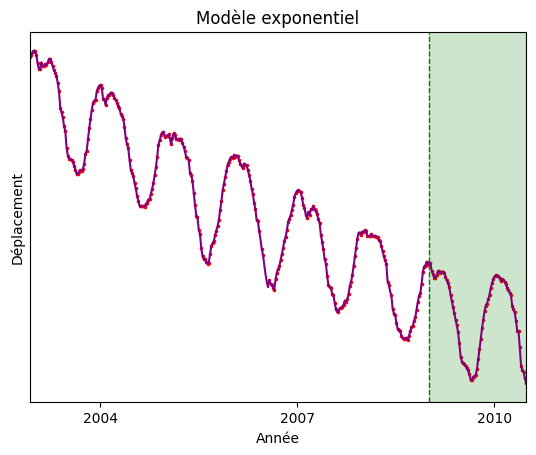

In [15]:

scaled_exp_index = model.get_states_index("scaled exp")
periodic_index = model.get_states_index("lstm")
autoregression_index = model.get_states_index("autoregression")
level_index = model.get_states_index("level")
cov_scaled_exp_auto = []
cov_scaled_exp_periodic = []
cov_periodic_auto = []
cov_periodic_level = []
cov_scaled_exp_level = []
cov_level_auto = []

all_dates = data_processor1.data.index
n_train = len(train_data["y"])
n_validation = len(validation_data["y"])
# 1 = len(test_data["y"])
# 1 = 0
train_dates = all_dates[: (n_train + n_validation)]
all_y_values = data_processor1.get_data("all")

slice_idx = slice(len(all_dates) - n_train - n_validation - 1, len(all_dates))
dates_plot = all_dates[slice_idx]
y_true_plot = all_y_values[slice_idx]
my_width = 2.5
my_height = 1.6

for i in range(len(model.states.get_mean("scaled exp", states_type="smooth"))):
    cov_scaled_exp_periodic.append(
        model.states.var_posterior[i][scaled_exp_index, periodic_index]
    )
    cov_scaled_exp_auto.append(
        model.states.var_posterior[i][
            scaled_exp_index, model.get_states_index("autoregression")
        ]
    )
    cov_periodic_auto.append(
        model.states.var_posterior[i][periodic_index, autoregression_index]
    )
    cov_periodic_level.append(
        model.states.var_posterior[i][periodic_index, level_index]
    )
    cov_scaled_exp_level.append(
        model.states.var_posterior[i][scaled_exp_index, level_index]
    )
    cov_level_auto.append(
        model.states.var_posterior[i][level_index, autoregression_index]
    )

cov_scaled_exp_auto = np.array(cov_scaled_exp_auto)
cov_scaled_exp_periodic = np.array(cov_scaled_exp_periodic)
cov_periodic_auto = np.array(cov_periodic_auto)
cov_scaled_exp_level = np.array(cov_scaled_exp_level)
cov_level_auto = np.array(cov_level_auto)
cov_periodic_level = np.array(cov_periodic_level)

print(len(model.states.get_mean("scaled exp", states_type="posterior")))
print(len(all_dates[
        len(all_dates) - n_train - n_validation-1 : len(all_dates)-1
    ]))

y_mean_expo = (
    model.states.get_mean("scaled exp", states_type="posterior")
    + model.states.get_mean("lstm", states_type="posterior")
    # + model.states.get_mean("autoregression", "posterior")
    + model.states.get_mean("level", states_type="posterior")
)
y_std_expo = np.sqrt(
    model.states.get_std("scaled exp", states_type="posterior") ** 2
    + model.states.get_std("lstm", states_type="posterior") ** 2
    # + model.states.get_std("autoregression", "posterior") ** 2
    + model.states.get_std("level", states_type="posterior") ** 2
    + 2
    * (
        cov_scaled_exp_periodic
        # + cov_scaled_exp_auto
        # + cov_periodic_auto
        + cov_scaled_exp_level
        # + cov_level_auto
        + cov_periodic_level
    )
)
plt.plot(
    all_dates[len(all_dates) - n_train - n_validation-1 : len(all_dates)],
    y_mean_expo,
    color="purple",
) 

plt.fill_between(
    all_dates[
        len(all_dates) - n_train - n_validation -1: len(all_dates)
    ],  # <--- PAS np.arange
    y_mean_expo + y_std_expo,
    y_mean_expo - y_std_expo,
    color="purple",
    alpha=0.3,
    edgecolor="none",
)
plt.scatter(
    all_dates[
        len(all_dates) - n_train - n_validation -1 : len(all_dates)
    ],  # <--- PAS np.arange
    all_y_values[
        len(all_dates) - n_train - n_validation -1 : len(all_dates)
    ],  # <--- Y correspondant
    color="red",
    s=2.5,
)
plt.axvline(
    x=pd.to_datetime(f"{last_year-1}"),
    color="green",  # Ou la couleur de votre choix
    linestyle="--",  # Style en tirets
    linewidth=1,
)
plt.axvspan(
    xmin=pd.to_datetime(f"{last_year-1}"),
    xmax=pd.to_datetime(pd.to_datetime(dates_plot[-1])),
    color="green",  # Couleur de base
    alpha=0.2,  # Transparence pour obtenir un "vert clair",
)
# --- FIN DE LA CORRECTION ---

ax = plt.gca()
ax.set_yticks([])
# Formate l'étiquette pour n'afficher que l'année
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
# Met une étiquette tous les 3 ans
ax.xaxis.set_major_locator(mdates.YearLocator(base=3))
# Force les limites min/max de l'axe
ax.set_xlim(pd.to_datetime(dates_plot[0]), pd.to_datetime(pd.to_datetime(dates_plot[-1])))
# --- Fin de la modification ---

plt.title("Modèle exponentiel")
plt.xlabel("Année")
plt.ylabel("Déplacement")
plt.show()


In [16]:
states_data1 = model.states
mu_data1 = model.states.mu_posterior
var_data1 = model.states.var_posterior
std_data1 = np.sqrt(np.diagonal(var_data1, axis1=1, axis2=2))
std_vec1 = std_data1[:, :, None]

In [17]:
data_processor2 = DataProcess(
    data=df_part2,
    train_split=0.7,
    validation_split=0.3,
    output_col=[0],
    standardization=False,
)

train_data2, validation_data2, _, all_data2 = data_processor2.get_splits()
# model.filter(data=train_data2[:9])
index_debut_validation = len(train_data2["y"])
date_debut_val = df_part2.index[index_debut_validation]
date_fin_val = df_part2.index[-1]
mu_posterior = model.states.mu_posterior[-1]
var_posterior = model.states.var_posterior[-1]
model.var_states[0, 0] += (model.mu_states[0].item() * 0.6) ** 2
model.var_states[1, 1] += (model.mu_states[1].item() * 0.15) ** 2
model.var_states[2, 2] += (model.mu_states[2].item() * 0.3) ** 2
model.var_states[-1, -1] += (model.mu_states[-1].item() * 0.05) ** 2
model.mu_states[0] = model.mu_states[0] * 0.55
# model.mu_states[1] += -model.mu_states[1]*0.4
# model.mu_states[2] += model.mu_states[2]*0.6
model.mu_states[-1] += (model.states.mu_posterior[-1][4]
    - (np.exp(-model.mu_states[0] + 0.5 * model.var_states[0, 0]) - 1)* model.mu_states[2]
    )
idx_reset = [0, 1, 2, 3, 4]

# 2. Créer un masque de "ce qu'il faut garder"
# Par défaut, on veut tout garder...
mask_keep = np.ones(model.var_states.shape, dtype=bool)

# ... SAUF les liens qui impliquent nos indices touchés
# On dit : si une ligne OU une colonne fait partie des indices reset, on ne garde pas (False)
mask_keep[idx_reset, :] = False
mask_keep[:, idx_reset] = False

# 3. Exception : On veut quand même garder la diagonale (la variance propre) des éléments reset
# (Car vous allez probablement la booster juste après, ou vous voulez garder l'incertitude actuelle)
np.fill_diagonal(mask_keep, True)
model.var_states[~mask_keep] = 0.0
print(model.var_states)

[[ 6.17722056e-01  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  2.37013911e-07  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.57669409e+01  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.51611059e-06
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   5.32916810e-04  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  

[4.68547714e-01 4.86840684e-04 3.92116502e+00 2.46730742e-01
 3.60815029e+00 4.69392205e-02 4.69392205e-02 3.11592484e-03
 2.08601088e-04 4.47227697e-01 1.32726421e-01]
['latent level', 'latent trend', 'exp scale factor', 'exp', 'scaled exp', 'autoregression', 'AR_error', 'W2', 'W2bar', 'lstm', 'level']
            Deplacements cumulatif X (mm)
Date                                     
2010-07-04                     -12.384286
2010-07-11                     -13.298571
2010-07-18                     -13.857857
2010-07-25                     -14.024286
2010-08-01                     -14.132857
...                                   ...
2014-09-28                     -19.505000
2014-10-05                     -19.405714
2014-10-12                     -19.246429
2014-10-19                     -19.089286
2014-10-26                     -18.888571

[226 rows x 1 columns]


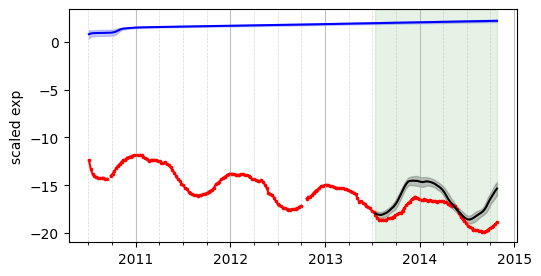

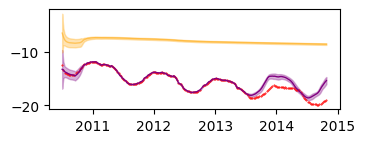

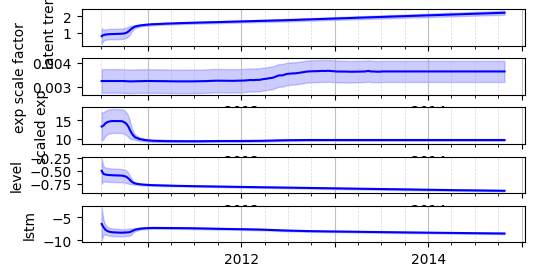

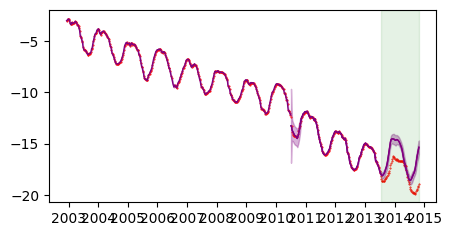

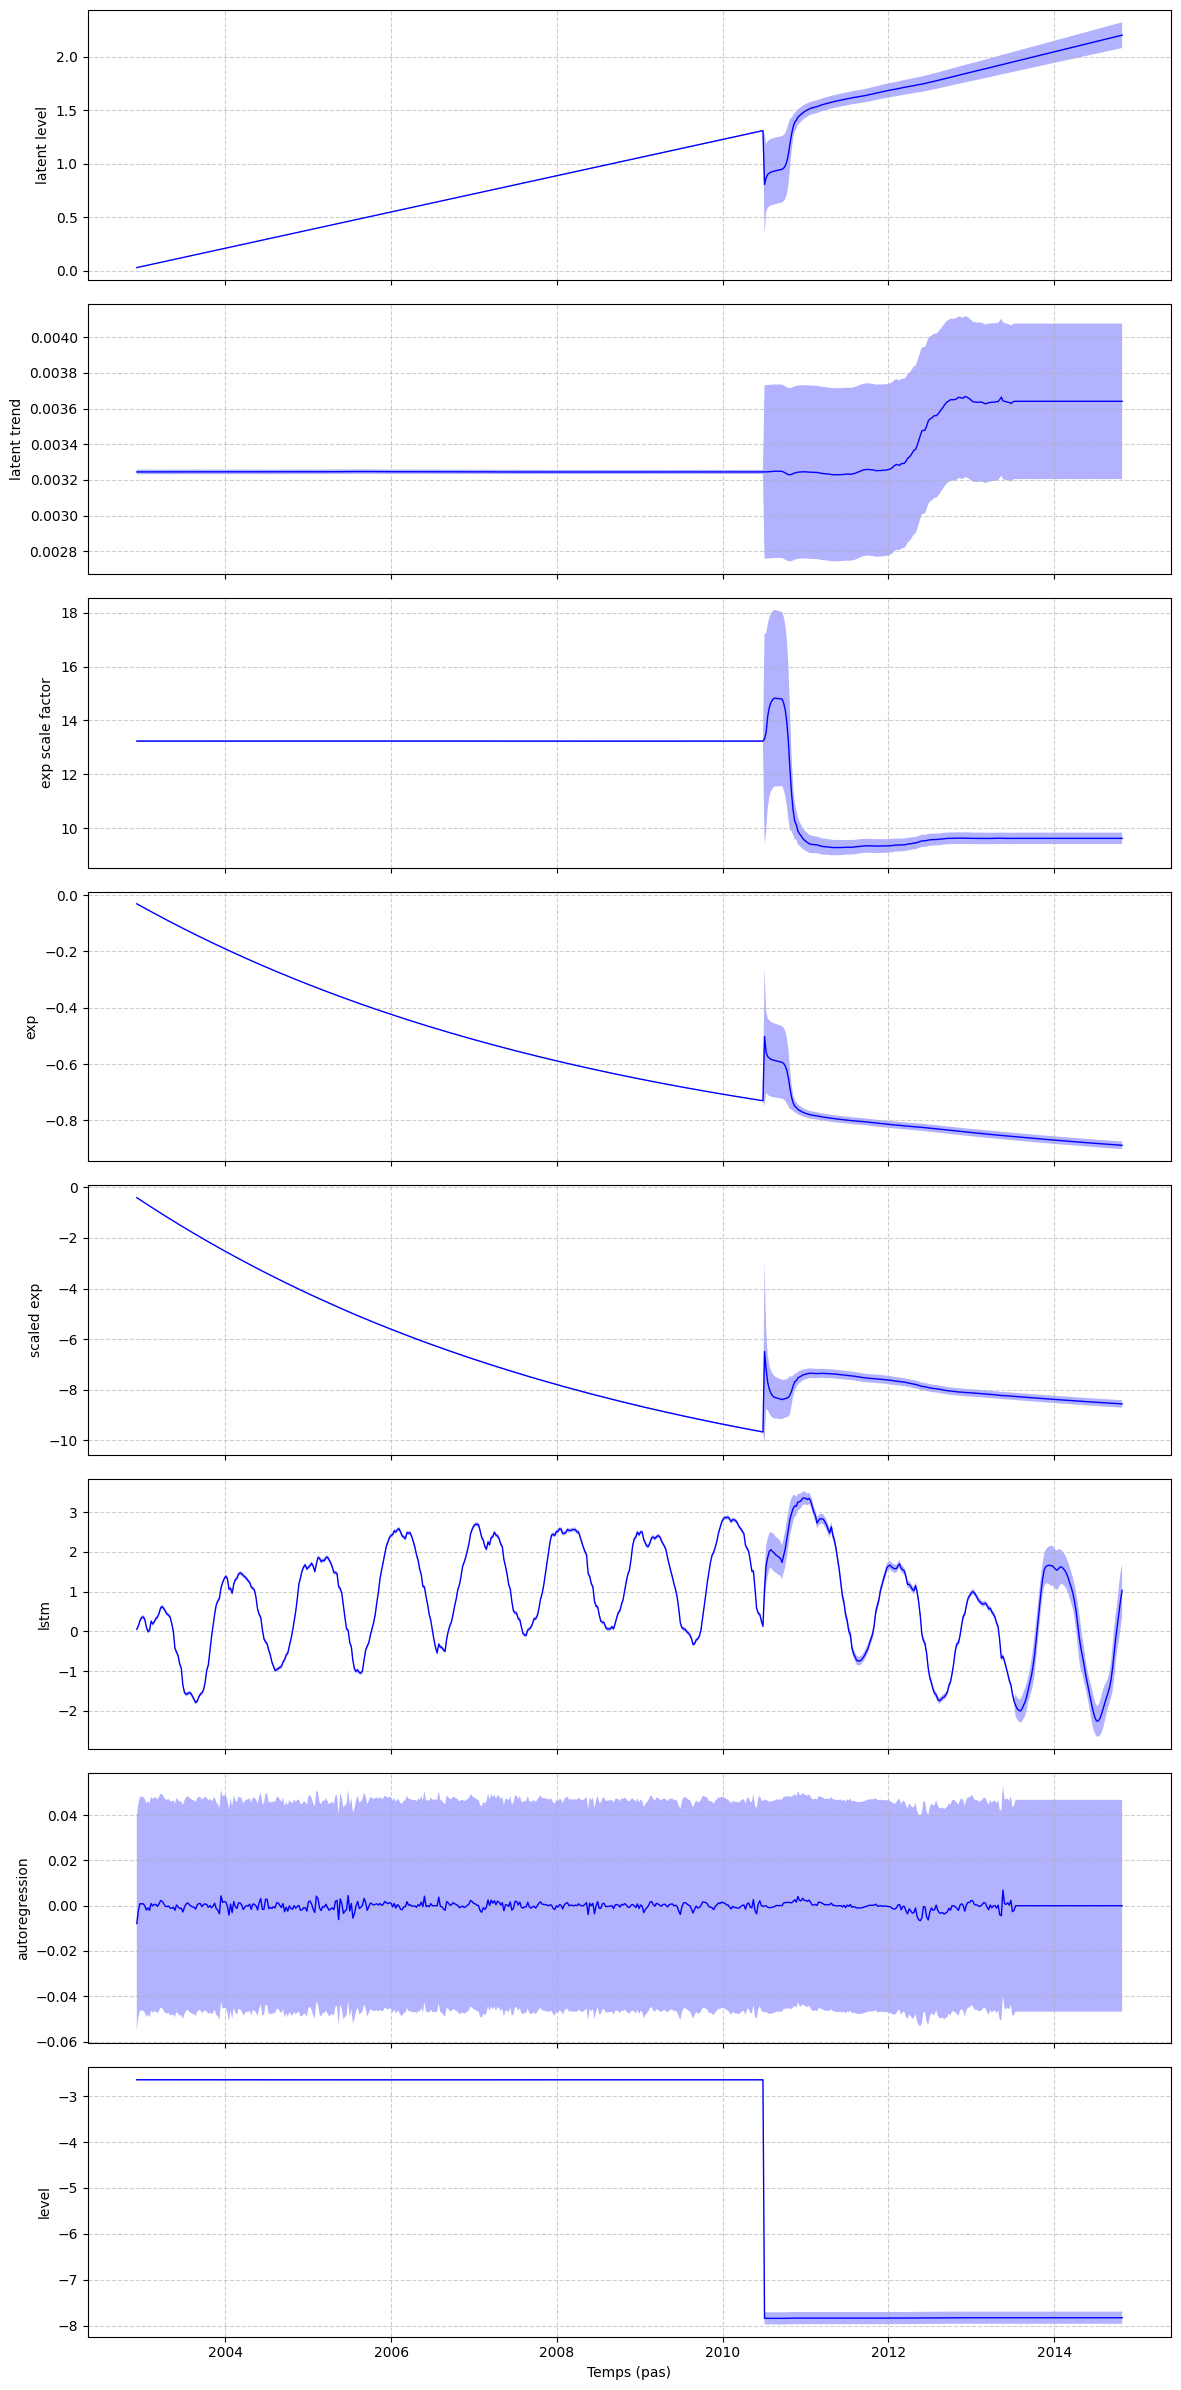

In [18]:
df_train2=pd.DataFrame(index=train_data2["time"], data={'y':train_data2["y"].flatten()})
# model.auto_initialize_comp(data_training=df_train2,ratio_training=0.6)
model.filter(data=train_data2)
mu_val, std_val, states = model.forecast(data=validation_data2)
states_data2 = model.states
mu_data2 = model.states.mu_posterior
var_data2 = model.states.var_posterior
std_data2 = np.sqrt(np.diagonal(var_data2, axis1=1, axis2=2))
print(std_data2[0])
std_vec2 = std_data2[:, :, None]

mu_data_all = mu_data1 + mu_data2
var_data_all = var_data1 + var_data2
std_vec_all = np.concatenate((std_vec1, std_vec2), axis=0)

mu_data_all = np.array(mu_data_all)
var_data_all = np.array(var_data_all)


# states_alldata = np.concatenate((states_data1, states_data2))
fig, ax = plot_states(
    data_processor=data_processor2,
    states=states,
    states_to_plot=["scaled exp"],
    states_type="posterior",
)
plot_data(
    data_processor=data_processor2,
    plot_train_data=True,
    plot_test_data=False,
    plot_validation_data=True,
    sub_plot=ax[0],
)
plot_prediction(
    data_processor=data_processor2,
    mean_validation_pred=mu_val,
    std_validation_pred=std_val,
    sub_plot=ax[0],
    color="k",
)
fig.set_size_inches(5, 2.5)

plt.scatter(df_part2.index, data_processor2.get_data("all"), color="red", s=2.5)

scaled_exp_index = model.get_states_index("scaled exp")
periodic_index = model.get_states_index("lstm")
autoregression_index = model.get_states_index("autoregression")
level_index = model.get_states_index("level")
cov_scaled_exp_auto = []
cov_scaled_exp_periodic = []
cov_periodic_auto = []
cov_periodic_level = []
cov_scaled_exp_level = []
cov_level_auto = []
for i in range(len(model.states.get_mean("scaled exp", states_type="smooth"))):
    cov_scaled_exp_periodic.append(
        model.states.var_posterior[i][scaled_exp_index, periodic_index]
    )
    cov_scaled_exp_auto.append(
        model.states.var_posterior[i][
            scaled_exp_index, model.get_states_index("autoregression")
        ]
    )
    cov_periodic_auto.append(
        model.states.var_posterior[i][periodic_index, autoregression_index]
    )
    cov_periodic_level.append(model.states.var_posterior[i][periodic_index, level_index])
    cov_scaled_exp_level.append(
        model.states.var_posterior[i][scaled_exp_index, level_index]
    )
    cov_level_auto.append(model.states.var_posterior[i][level_index, autoregression_index])

cov_scaled_exp_auto = np.array(cov_scaled_exp_auto)
cov_scaled_exp_periodic = np.array(cov_scaled_exp_periodic)
cov_periodic_auto = np.array(cov_periodic_auto)
cov_scaled_exp_level = np.array(cov_scaled_exp_level)
cov_level_auto = np.array(cov_level_auto)
cov_periodic_level = np.array(cov_periodic_level)

y_mean_expo_sinus_level2 = (
    model.states.get_mean("scaled exp", states_type="posterior")
    + model.states.get_mean("lstm", states_type="posterior")
    # + model.states.get_mean("autoregression", states_type="posterior")
    + model.states.get_mean("level", states_type="posterior")
)
y_std_expo_sinus_level2 = np.sqrt(
    model.states.get_std("scaled exp", states_type="posterior") ** 2
    + model.states.get_std("lstm", states_type="posterior") ** 2
    # + model.states.get_std("autoregression", states_type="posterior") ** 2
    + model.states.get_std("level", states_type="posterior") ** 2
    + 2
    * (
        cov_scaled_exp_periodic
        # + cov_scaled_exp_auto
        # + cov_periodic_auto
        + cov_scaled_exp_level
        # + cov_level_auto
        + cov_periodic_level
    )
)
plt.figure(figsize=(3.75, 1.3))
plt.plot(
    df_part2.index,
    y_mean_expo_sinus_level2,
    color="purple",
    linewidth=1,
)
plt.fill_between(
    df_part2.index,
    y_mean_expo_sinus_level2 + y_std_expo_sinus_level2,
    y_mean_expo_sinus_level2 - y_std_expo_sinus_level2,
    color="purple",
    alpha=0.3,
)
plt.scatter(
    df_part2.index,
    data_processor2.get_data("all"),
    s=0.2,
    color="red",
)

plt.plot(
    df_part2.index,
    model.states.get_mean("scaled exp", states_type="posterior"),
    color="orange",
    linewidth=1,
    alpha=0.5,
)
plt.fill_between(
    df_part2.index,
    model.states.get_mean("scaled exp", states_type="posterior")
    + model.states.get_std("scaled exp", states_type="posterior"),
    model.states.get_mean("scaled exp", states_type="posterior")
    - model.states.get_std("scaled exp", states_type="posterior"),
    color="orange",
    alpha=0.3,
)


ax = plt.gca()  # Récupérer l'axe courant
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig, axes = plot_states(
    data_processor=data_processor2,
    states=model.states,
    states_type="posterior",
    states_to_plot=(
        # "latent level",
        "latent trend",
        "exp scale factor",
        #     "exp",
        "scaled exp",
        "level",
        #     "trend",
        "lstm",
        # "autoregression",
    ),
)
if not isinstance(axes, (list, np.ndarray)):
    axes = [axes]

    # Réduit les ticks sur chaque subplot
for ax in axes:
    for k, label in enumerate(ax.get_xticklabels()):
        label.set_visible(k % 2 == 0)
axes[0].tick_params(labelbottom=False)

fig.set_size_inches(5, 2.5)

plt.figure(figsize=(5, 2.5))
plt.plot(
    df_part1.index,
    y_mean_expo,
    color="purple",
    linewidth=1,
)
plt.fill_between(
    df_part1.index,
    y_mean_expo + y_std_expo,
    y_mean_expo - y_std_expo,
    color="purple",
    alpha=0.3,
)
plt.scatter(
    df_part1.index,
    data_processor1.get_data("all"),
    s=0.2,
    color="red",
)


plt.plot(
    df_part2.index,
    y_mean_expo_sinus_level2,
    color="purple",
    linewidth=1,
)
plt.fill_between(
    df_part2.index,
    y_mean_expo_sinus_level2 + y_std_expo_sinus_level2,
    y_mean_expo_sinus_level2 - y_std_expo_sinus_level2,
    color="purple",
    alpha=0.3,
)
plt.scatter(
    df_part2.index,
    data_processor2.get_data("all"),
    s=0.2,
    color="red",
)
plt.plot(
    df_part2.index,
    y_mean_expo_sinus_level2,
    color="purple",
    linewidth=1,
    label="Modèle global",  # Ajout d'un label pour la légende
)

# --- AJOUT DE LA ZONE DE VALIDATION ---
plt.axvspan(
    date_debut_val,
    date_fin_val,
    color="green",
    alpha=0.1,
    label="Zone Validation (Part 2)",
)

ax = plt.gca()  # Récupérer l'axe courant
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# indices 11 : 0 XEL 1 XET 2 XES 3 exp 4 scaled exp 5 6 7 8 9 periodic 1 10 periodic 2 11 level


def plot_states(mu, std, states_indices=None, states_names=None):
    """
    mu, std : arrays de shape (T, N_states, 1)
    states_indices : liste des indices d'états à afficher (ex: [0, 2, 5]). Si None, affiche tout.
    states_names : liste des noms pour le titre (optionnel)
    """

    # Si aucun indice n'est spécifié, on prend tout
    if states_indices is None:
        states_indices = range(mu.shape[1])

    n_plots = len(states_indices)

    # Création d'une figure avec des sous-graphiques (1 colonne, n lignes)
    # figsize : largeur=12, hauteur = 3 * nombre de graphiques
    fig, axes = plt.subplots(
        nrows=n_plots, ncols=1, figsize=(12, 3 * n_plots), sharex=True
    )

    # Si on n'a qu'un seul état, axes n'est pas une liste, on le met dans une liste
    if n_plots == 1:
        axes = [axes]

    # Boucle sur les états choisis
    for i, ax in enumerate(axes):
        state_idx = states_indices[i]

        # 1. Extraction des données (et suppression de la dimension inutile '1')
        # On passe de (725, 1) à (725,)
        y = mu[:, state_idx, 0]
        err = std[:, state_idx, 0]
        x = df_part1.index.append(df_part2.index)  # ou votre vecteur temps réel

        # 2. Bornes sup et inf
        lower_bound = y - err
        upper_bound = y + err

        # 3. Plot de la moyenne (Ligne solide)
        ax.plot(x, y, label="Moyenne", color="blue", linewidth=1)

        # 4. Plot de la zone d'incertitude (Zone ombrée)
        # alpha gère la transparence (0.0 transparent, 1.0 opaque)
        ax.fill_between(
            x,
            lower_bound,
            upper_bound,
            color="blue",
            alpha=0.3,
            label="std dev",
            edgecolor="none",
        )

        # Esthétique
        ax.grid(True, linestyle="--", alpha=0.6)
        ax.set_ylabel(model.states.states_name[state_idx], fontsize=10)

    plt.xlabel("Temps (pas)")
    plt.tight_layout()  # Ajuste automatiquement les espacements pour que ce soit joli
    plt.show()


# --- UTILISATION ---

# Par exemple, on veut afficher seulement l'état 0, l'état 3 et l'état 11
print(model.states.states_name)
indices_a_voir = [
    model.get_states_index("latent level"),
    model.get_states_index("latent trend"),
    model.get_states_index("exp scale factor"),
    model.get_states_index("exp"),
    model.get_states_index("scaled exp"),
    model.get_states_index("lstm"),
    model.get_states_index("autoregression"),
    model.get_states_index("level"),
]
noms_des_etats = model.states.states_name  # Votre liste complète
print(df_part2)
plot_states(
    mu_data_all, std_vec_all, states_indices=indices_a_voir, states_names=noms_des_etats
)
